In [196]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from tensorflow.keras.optimizers import Adam
import datetime


In [3]:
df = pd.read_csv('Churn_Modelling.csv')
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [5]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [9]:
df.drop(columns = ['RowNumber','CustomerId','Surname'],inplace = True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [13]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Univariate Analysis

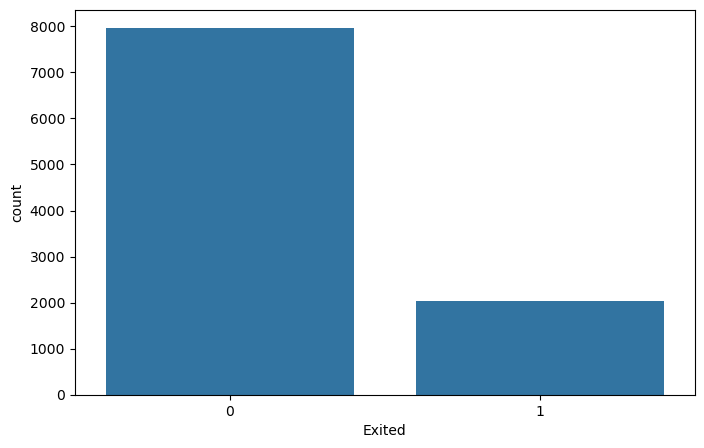

In [89]:
plt.figure(figsize = (8,5))
sns.countplot(x = df['Exited'], data = df)
plt.show()

### Bivariate Analysis

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


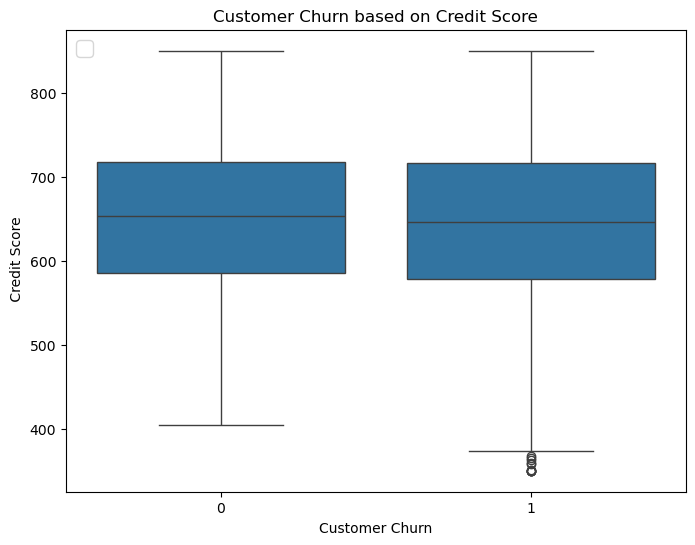

In [69]:
plt.figure(figsize =(8,6))
sns.boxplot(y = df['CreditScore'],x=df['Exited'],data=df)
plt.xlabel('Customer Churn')
plt.ylabel(' Credit Score')
plt.title('Customer Churn based on Credit Score')
plt.legend(loc ='upper left',fontsize = 15)
plt.show()

In [110]:
# Calulate Median
median_credit_score = df.groupby('Exited')['CreditScore'].median()
print(median_credit_score)
print(median_credit_score[1]-median_credit_score[0])

Exited
0    653.0
1    646.0
Name: CreditScore, dtype: float64
-7.0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


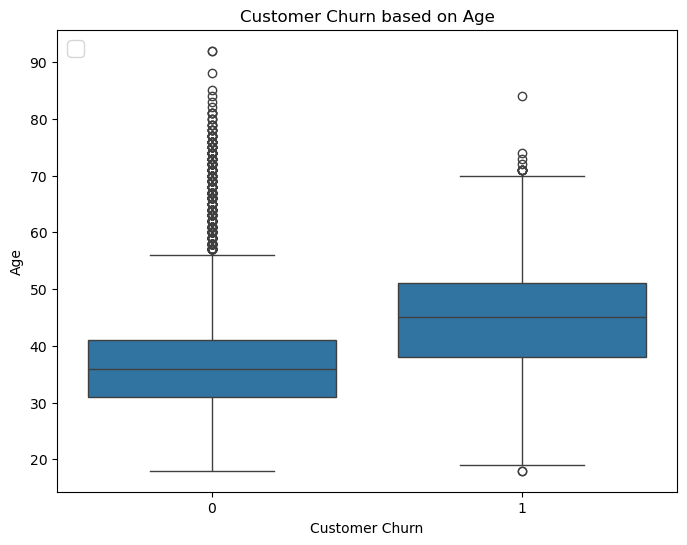

In [71]:
plt.figure(figsize =(8,6))
sns.boxplot(y = df['Age'],x=df['Exited'],data=df)
plt.ylabel('Age')
plt.xlabel('Customer Churn')
plt.title('Customer Churn based on Age')
plt.legend(loc ='upper left',fontsize = 15)
plt.show()

In [108]:
# median
median_age = df.groupby('Exited')['Age'].median()
print(median_age)
print(median_age[1]-median_age[0])

Exited
0    36.0
1    45.0
Name: Age, dtype: float64
9.0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


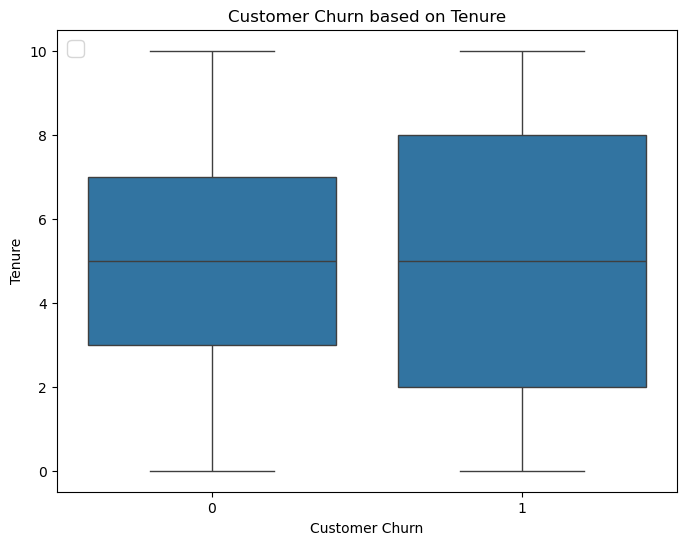

In [73]:
plt.figure(figsize =(8,6))
sns.boxplot(y = df['Tenure'],x=df['Exited'],data=df)
plt.ylabel('Tenure')
plt.xlabel('Customer Churn')
plt.title('Customer Churn based on Tenure')
plt.legend(loc ='upper left',fontsize = 15)
plt.show()

In [112]:
#median
median_tenure = df.groupby('Exited')['Tenure'].median()
print(median_tenure)
print(median_tenure[1]-median_tenure[0])

Exited
0    5.0
1    5.0
Name: Tenure, dtype: float64
0.0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


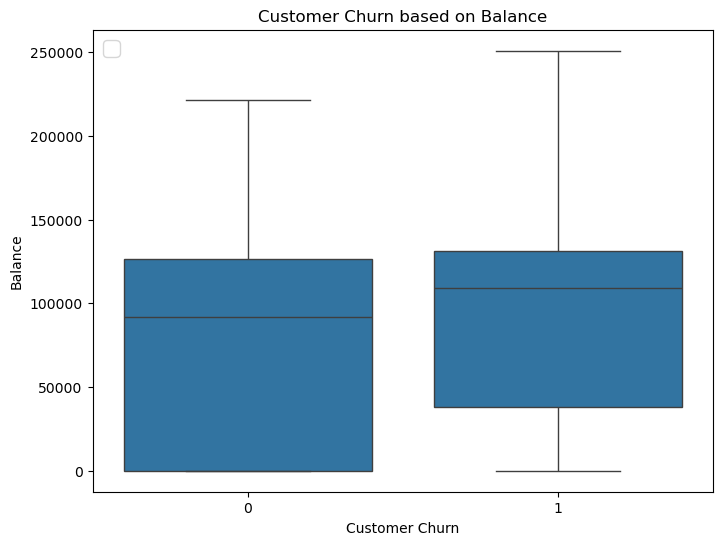

In [77]:
plt.figure(figsize =(8,6))
sns.boxplot(y = df['Balance'],x=df['Exited'],data=df)
plt.ylabel('Balance')
plt.xlabel('Customer Churn')
plt.title('Customer Churn based on Balance')
plt.legend(loc ='upper left',fontsize = 15)
plt.show()

In [114]:
# median
median_balance = df.groupby('Exited')['Balance'].median()
print(median_balance)
print(median_balance[0]-median_balance[1])

Exited
0     92072.68
1    109349.29
Name: Balance, dtype: float64
-17276.61


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


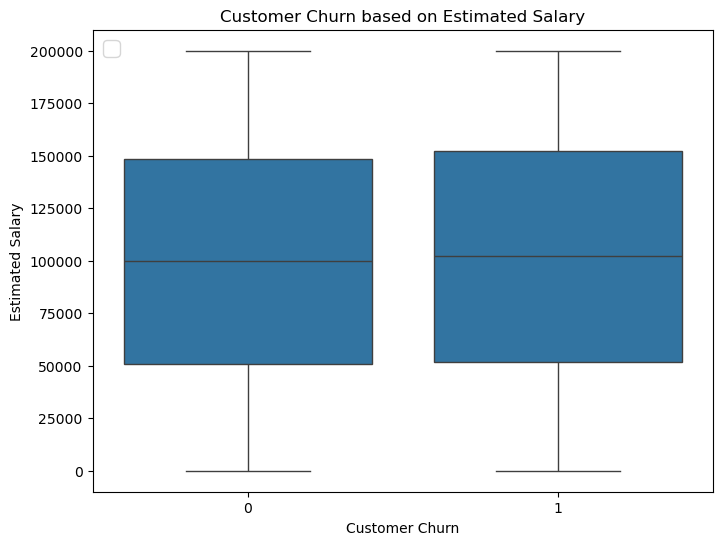

In [79]:
plt.figure(figsize =(8,6))
sns.boxplot(y = df['EstimatedSalary'],x=df['Exited'],data=df)
plt.ylabel('Estimated Salary')
plt.xlabel('Customer Churn')
plt.title('Customer Churn based on Estimated Salary')
plt.legend(loc ='upper left',fontsize = 15)
plt.show()

In [116]:
# median
median_salary = df.groupby('Exited')['EstimatedSalary'].median()
print(median_salary)
print(median_salary[1]-median_salary[0])

Exited
0     99645.04
1    102460.84
Name: EstimatedSalary, dtype: float64
2815.800000000003


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


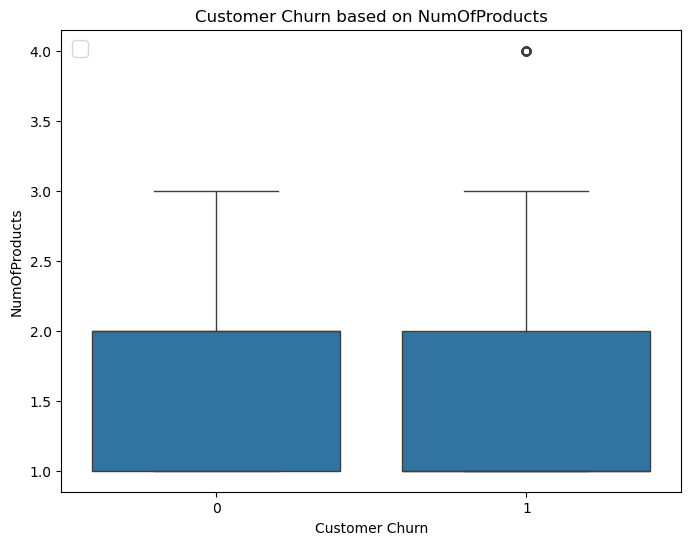

In [81]:
plt.figure(figsize =(8,6))
sns.boxplot(y = df['NumOfProducts'],x=df['Exited'],data=df)
plt.ylabel('NumOfProducts')
plt.xlabel('Customer Churn')
plt.title('Customer Churn based on NumOfProducts')
plt.legend(loc ='upper left',fontsize = 15)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


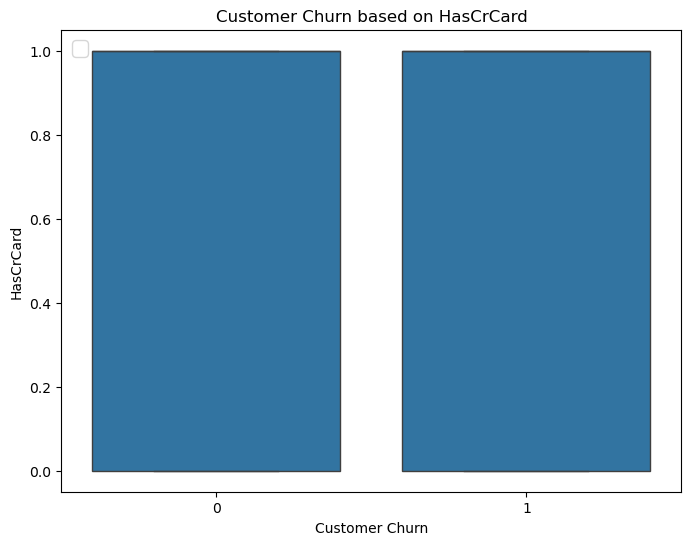

In [83]:
plt.figure(figsize =(8,6))
sns.boxplot(y = df['HasCrCard'],x=df['Exited'],data=df)
plt.ylabel('HasCrCard')
plt.xlabel('Customer Churn')
plt.title('Customer Churn based on HasCrCard')
plt.legend(loc ='upper left',fontsize = 15)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


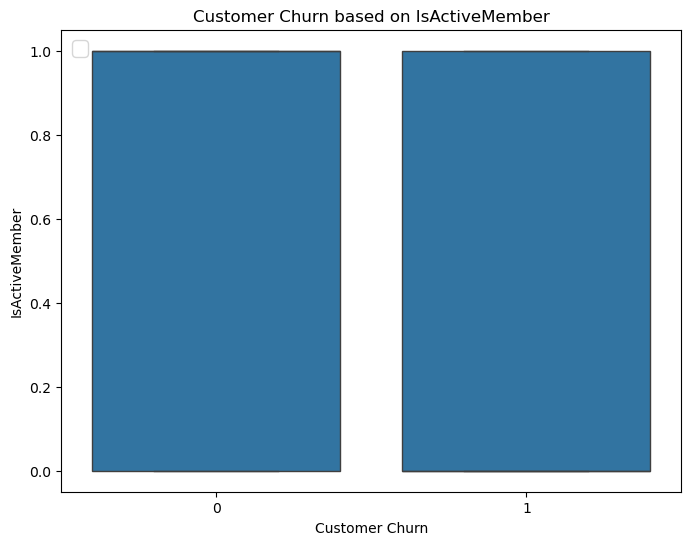

In [85]:
plt.figure(figsize =(8,6))
sns.boxplot(y = df['IsActiveMember'],x=df['Exited'],data=df)
plt.ylabel('IsActiveMember')
plt.xlabel('Customer Churn')
plt.title('Customer Churn based on IsActiveMember')
plt.legend(loc ='upper left',fontsize = 15)
plt.show()

In [ ]:
CreditScore, age, Balance

### Encoding using label Encoder

In [134]:
label_encode_gender = LabelEncoder()
df['Gender'] = label_encode_gender.fit_transform(df['Gender'])
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64,0
9996,516,France,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,0,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1


### One Hot Encoding

In [146]:
encoding_geo = OneHotEncoder()
geo_encoded = encoding_geo.fit_transform(df[['Geography']])
geo_df = pd.DataFrame(geo_encoded.toarray(),columns = encoding_geo.get_feature_names_out(['Geography']))
df = pd.concat([df,geo_df],axis = 1)

df


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Geography_France,Geography_Germany,Geography_Spain
0,619,France,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0,1.0,0.0,0.0
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0,0.0,0.0,1.0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0,1.0,0.0,0.0
3,699,France,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0,1.0,0.0,0.0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64,0,1.0,0.0,0.0,1.0,0.0,0.0
9996,516,France,1,35,10,57369.61,1,1,1,101699.77,0,1.0,0.0,0.0,1.0,0.0,0.0
9997,709,France,0,36,7,0.00,1,0,1,42085.58,1,1.0,0.0,0.0,1.0,0.0,0.0
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1,0.0,1.0,0.0,0.0,1.0,0.0


In [150]:
df.drop('Geography',axis = 1,inplace = True)

In [152]:
df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,1.0,0.0,0.0,1.0,0.0,0.0
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,1.0,0.0,0.0,1.0,0.0,0.0
9997,709,0,36,7,0.00,1,0,1,42085.58,1,1.0,0.0,0.0,1.0,0.0,0.0
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,0.0,1.0,0.0,0.0,1.0,0.0


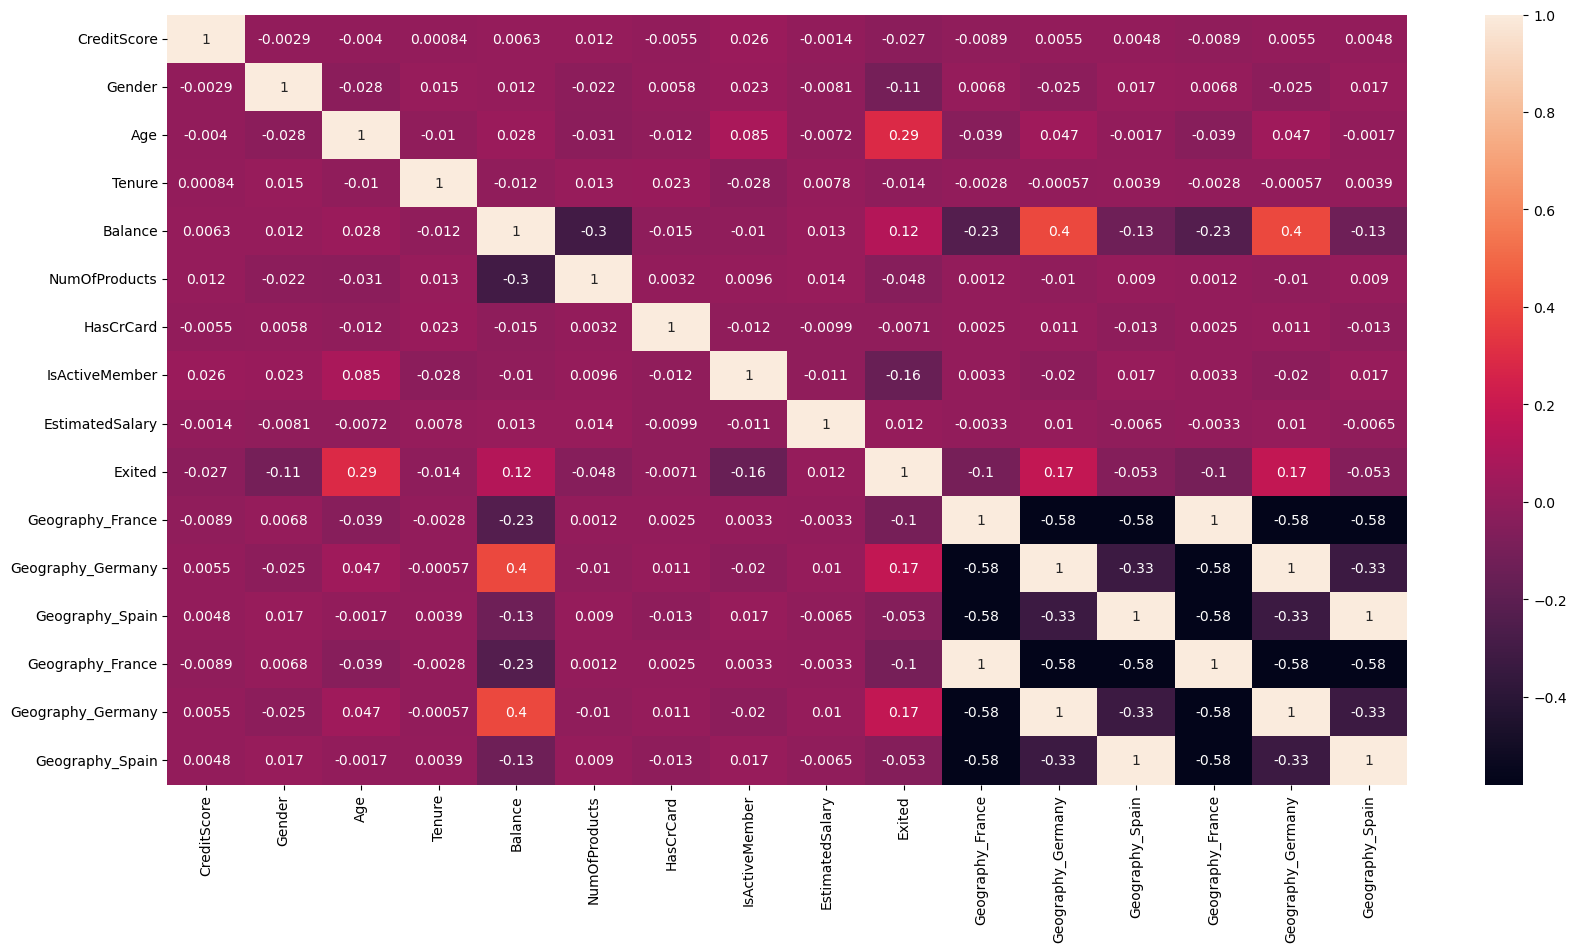

In [166]:
correlation  = df.corr()
plt.figure(figsize = (20,10))
sns.heatmap(correlation, annot = True)
plt.show()

### Split into dependent and independent variables

In [186]:
X = df.drop('Exited', axis =1)
y = df['Exited']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Build ANN

In [192]:
model = Sequential()
model.add(Dense(64,activation = 'relu',input_shape = (X_train_scaled.shape[1],)))
model.add(Dense(32,activation = 'relu'))
model.add(Dense(1,activation = 'sigmoid'))

In [194]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 64)                  │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [200]:
model.compile(optimizer = Adam(learning_rate = 0.01) , loss='binary_crossentropy' , metrics = ['accuracy'] )

In [202]:
# Set up the tensorboard callback
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Set up early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [206]:
history = model.fit(X_train_scaled,
                    y_train,
                    validation_data = (X_test_scaled,y_test),
                    epochs = 100, 
                    callbacks = [tensorboard_callback,early_stopping])

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8164 - loss: 0.4359 - val_accuracy: 0.8610 - val_loss: 0.3513
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8475 - loss: 0.3599 - val_accuracy: 0.8600 - val_loss: 0.3472
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8652 - loss: 0.3435 - val_accuracy: 0.8610 - val_loss: 0.3409
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8577 - loss: 0.3440 - val_accuracy: 0.8590 - val_loss: 0.3422
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8591 - loss: 0.3331 - val_accuracy: 0.8565 - val_loss: 0.3488
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8516 - loss: 0.3524 - val_accuracy: 0.8520 - val_loss: 0.3520
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8602 - loss: 0.3419 - val_accuracy: 0.8630 - val_loss: 0.3464
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8668 - loss: 0.3260 - val_accu

In [208]:
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Get the raw probabilities from the model
y_pred_probs = model.predict(X_test_scaled)

# 2. Convert probabilities to 0 or 1 using the 0.5 threshold
y_pred_classes = (y_pred_probs >= 0.5).astype(int)

# 3. Calculate accuracy
acc = accuracy_score(y_test, y_pred_classes)
print(f"Calculated Accuracy: {acc * 100:.2f}%")

# 4. View the True Positives, True Negatives, etc.
cm = confusion_matrix(y_test, y_pred_classes)
print("Confusion Matrix:\n", cm)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Calculated Accuracy: 86.15%
Confusion Matrix:
 [[1548   59]
 [ 218  175]]
